In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch

# בחירת מודל עברי (AlephBERT from OnlpLab - publicly available)
model_name = "onlplab/alephbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def represent_nli_pair(premise, hypothesis):
    # שילוב של ה-premise וה-hypothesis עם [SEP] token
    combined_text = premise + " [SEP] " + hypothesis

    # טוקניזציה עם Padding ו-Truncation למידה אחידה
    inputs = tokenizer(
        combined_text,
        return_tensors="pt",
        padding='max_length',
        truncation=True,
        max_length=128
    )

    # הפקת וקטורים (Embeddings) מהמודל
    with torch.no_grad():
        outputs = model(**inputs)

    # שימוש בוקטור ה-[CLS] (הראשון ברצף) כייצוג של כל הזוג
    cls_embedding = outputs.last_hidden_state[:, 0, :]

    return cls_embedding

# דוגמה מה-HebNLI
sample_premise = "הילד רץ בפארק"
sample_hypothesis = "הילד נמצא בחוץ"
representation = represent_nli_pair(sample_premise, sample_hypothesis)

print(f"Shape of representation: {representation.shape}") # אמור להיות [1, 768]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Shape of representation: torch.Size([1, 768])


In [4]:
!pip install pandas wordcloud matplotlib seaborn python-bidi arabic-reshaper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 16.3 MB/s eta 0:00:00


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from bidi.algorithm import get_display
import arabic_reshaper # נדרש כדי שהאותיות בעברית לא יתפרקו ב-WordCloud

# טעינת הנתונים - קובץ JSONL
df = pd.read_json('/content/drive/MyDrive/nlp_pro2/data_sets/cleaned/train.full.clean.jsonl', lines=True)

# בדיקה ראשונית של המבנה [מדרישות שלב א']
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299728 entries, 0 to 299727
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   translation1  299728 non-null  object
 1   translation2  299728 non-null  object
 2   label         299728 non-null  object
 3   genre         299728 non-null  object
 4   pairID        299728 non-null  object
dtypes: object(5)
memory usage: 11.4+ MB
None
                                        translation1  \
0  אז בכל מקרה, אולי הוא ישים את ווילי הורטון הזה...   
1            האם ניתנה תשומת לב מספקת לערכים חריגים?   
2  כפי שסוכם עם המשתתפים, מטרת הדיון לא הייתה להג...   
3      בפינה הימנית התחתונה, לחץ על , שייקח אותך ...   
4                                 שווה מיליון דולר!"   

                                     translation2          label       genre  \
0        לא הרבה אנשים יודעים מי זה ווילי הורטון.        neutral       slate   
1          לסטיות לא צריך לתת שום תשומת לב, נכ

Label Distribution

/tmp/ipython-input-3724736416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)


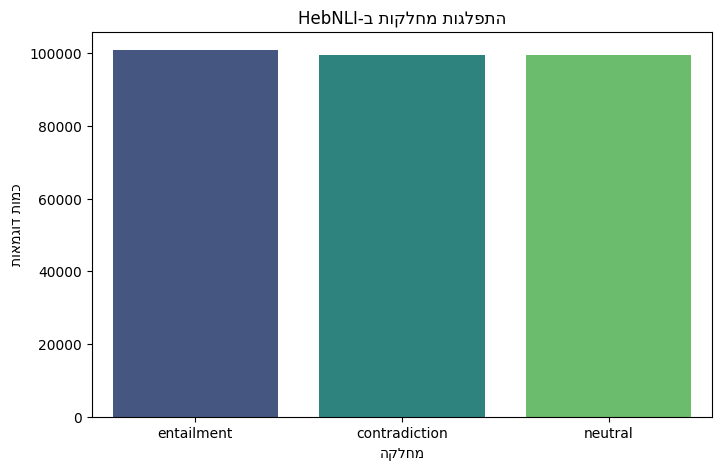

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)
plt.title(get_display("התפלגות מחלקות ב-HebNLI"))
plt.xlabel(get_display("מחלקה"))
plt.ylabel(get_display("כמות דוגמאות"))
plt.savefig('label_distribution.png')

# Sequence Length


/tmp/ipython-input-4290252815.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['premise_len'], label=get_display('Premise (הנחה)'), shade=True)
/tmp/ipython-input-4290252815.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['hypothesis_len'], label=get_display('Hypothesis (השערה)'), shade=True)


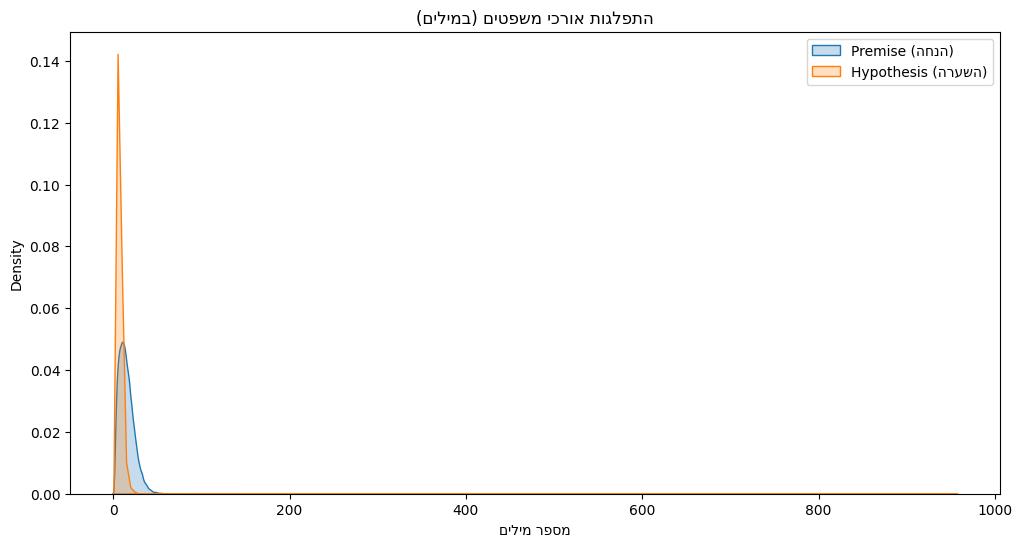

In [9]:
# חישוב אורך במילים (מדד פשוט ל-EDA)
df['premise_len'] = df['translation1'].str.split().str.len()
df['hypothesis_len'] = df['translation2'].str.split().str.len()

plt.figure(figsize=(12, 6))
sns.kdeplot(df['premise_len'], label=get_display('Premise (הנחה)'), shade=True)
sns.kdeplot(df['hypothesis_len'], label=get_display('Hypothesis (השערה)'), shade=True)
plt.title(get_display("התפלגות אורכי משפטים (במילים)"))
plt.xlabel(get_display("מספר מילים"))
plt.legend()
plt.savefig('text_length_dist.png')

In [23]:
import pandas as pd

# הנחה שה-DataFrame שלכם נקרא df
# ושהעמודות הן 'premise' ו-'hypothesis' (או השמות שנתתם להן)

# 1. יצירת עמודות חדשות של אורך (לפי מספר מילים)
df['premise_word_count'] = df['translation1'].apply(lambda x: len(str(x).split()))
df['hypothesis_word_count'] = df['translation2'].apply(lambda x: len(str(x).split()))

# 2. חישוב סטטיסטיקות עבור ההנחה (Premise)
avg_premise = df['premise_word_count'].mean()
max_premise = df['premise_word_count'].max()

# 3. חישוב סטטיסטיקות עבור ההשערה (Hypothesis)
avg_hypothesis = df['hypothesis_word_count'].mean()
max_hypothesis = df['hypothesis_word_count'].max()

# הדפסת התוצאות
print(f"--- נתוני הנחה (Premise) ---")
print(f"אורך ממוצע: {avg_premise:.2f} מילים")
print(f"אורך מקסימלי: {max_premise} מילים")

print(f"\n--- נתוני השערה (Hypothesis) ---")
print(f"אורך ממוצע: {avg_hypothesis:.2f} מילים")
print(f"אורך מקסימלי: {max_hypothesis} מילים")

--- נתוני הנחה (Premise) ---
אורך ממוצע: 14.66 מילים
אורך מקסימלי: 139 מילים

--- נתוני השערה (Hypothesis) ---
אורך ממוצע: 7.81 מילים
אורך מקסימלי: 957 מילים


In [24]:
import pandas as pd

# הנחה שהעמודות שלכם נקראות 'premise' ו-'hypothesis'
# (או 'translation1' ו-'translation2' כפי שהופיע בשגיאה הקודמת)

# 1. חישוב מספר התווים לכל שורה
df['premise_char_count'] = df['translation1'].str.len()
df['hypothesis_char_count'] = df['translation2'].str.len()

# 2. חישוב ממוצע ומקסימום עבור ההנחה (Premise)
avg_char_premise = df['premise_char_count'].mean()
max_char_premise = df['premise_char_count'].max()

# 3. חישוב ממוצע ומקסימום עבור ההשערה (Hypothesis)
avg_char_hypothesis = df['hypothesis_char_count'].mean()
max_char_hypothesis = df['hypothesis_char_count'].max()

# הדפסת התוצאות
print(f"--- סטטיסטיקת תווים (אותיות וסימנים) ---")
print(f"הנחה (Premise): ממוצע {avg_char_premise:.2f}, מקסימום {max_char_premise}")
print(f"השערה (Hypothesis): ממוצע {avg_char_hypothesis:.2f}, מקסימום {max_char_hypothesis}")

--- סטטיסטיקת תווים (אותיות וסימנים) ---
הנחה (Premise): ממוצע 83.61, מקסימום 826
השערה (Hypothesis): ממוצע 43.20, מקסימום 3829


In [27]:
from transformers import AutoTokenizer

# טעינת הטוקנייזר של המודל שבחרתם
tokenizer = AutoTokenizer.from_pretrained("onlplab/alephbert-base")

def count_tokens(row):
    # BERT ל-NLI מחבר את שני המשפטים עם [SEP] ביניהם
    tokens = tokenizer.encode(row['translation1'], row['translation2'], add_special_tokens=True)
    return len(tokens)

# חישוב אורך טוקנים לכל הדאטה
token_counts = df.apply(count_tokens, axis=1)

print(f"אורך טוקנים ממוצע: {token_counts.mean():.2f}")
print(f"אחוזון 95 (95% מהדאטה קצר מ...): {token_counts.quantile(0.95)}")
print(f"אחוזון 99 (99% מהדאטה קצר מ...): {token_counts.quantile(0.99)}")
print(f"אורך מקסימלי שנמצא: {token_counts.max()}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1013 > 512). Running this sequence through the model will result in indexing errors


אורך טוקנים ממוצע: 33.88
אחוזון 95 (95% מהדאטה קצר מ...): 60.0
אחוזון 99 (99% מהדאטה קצר מ...): 76.0
אורך מקסימלי שנמצא: 1013


we can see from here that we can set the max length to be 128 tokens

# ***Word cloud***

In [19]:
!wget https://github.com/google/fonts/raw/main/ofl/assistant/Assistant%5Bwght%5D.ttf -O assistant.ttf


--2026-01-30 07:18:00--  https://github.com/google/fonts/raw/main/ofl/assistant/Assistant%5Bwght%5D.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/assistant/Assistant%5Bwght%5D.ttf [following]
--2026-01-30 07:18:00--  https://raw.githubusercontent.com/google/fonts/main/ofl/assistant/Assistant%5Bwght%5D.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99496 (97K) [application/octet-stream]
Saving to: ‘assistant.ttf’

assistant.ttf       100%[===================>]  97.16K  --.-KB/s    in 0.003s  

2026-01-30 07:18:00 (31.2 MB/s) - ‘assistant.ttf’ saved [99496/9949

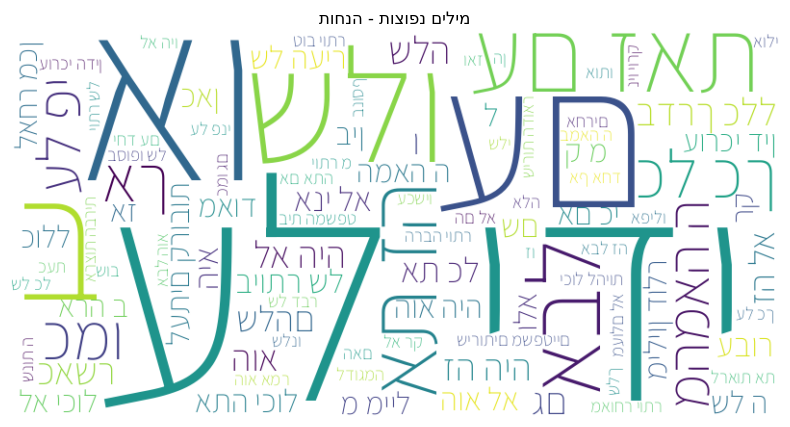

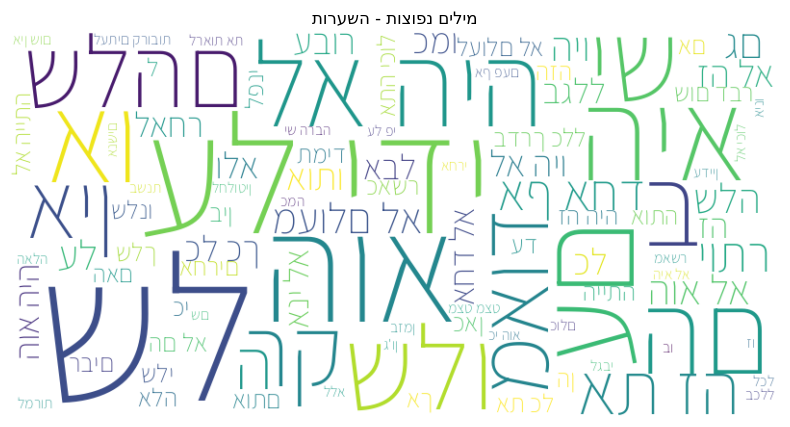

In [21]:
def create_hebrew_wordcloud(text_series, title):
    # חיבור כל הטקסט וטיפול בכיווניות (RTL)
    text = " ".join(text_series.dropna())
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)

    # עכשיו עדכנו את הפונקציה שלכם להשתמש בו:
    wordcloud = WordCloud(
        font_path='assistant.ttf',
        width=800, height=400,
        background_color='white',
        max_words=100
    ).generate(bidi_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(get_display(title))
    plt.savefig(f'{title}.png')

# יצירת ענני מילים בנפרד לכל חלק
create_hebrew_wordcloud(df['translation1'], "מילים נפוצות - הנחות")
create_hebrew_wordcloud(df['translation2'], "מילים נפוצות - השערות")

There are a lot of stop words
so we will remove a few

In [30]:
# הגדרת רשימת מילות עצירה מורחבת
hebrew_stopwords = [
    "את", "של", "על", "עם", "אל", "מה", "מי", "הוא", "היא", "הם", "הן",
    "זה", "זאת", "אלה", "היה", "היתה", "יהיה", "יש", "אין", "כל", "גם",
    "לכן", "אבל", "כי", "אם", "או", "אולי", "רק", "כבר", "עוד", "מאוד",
    "ממש", "שלי", "שלך", "שלו", "שלה", "אשר", "כש", "מהם", "מהן"
]

# פונקציה לניקוי הטקסט ממילות עצירה (Preprocessing) [cite: 13]
def remove_stopwords(text):
    words = str(text).split()
    clean_words = [w for w in words if w not in hebrew_stopwords]
    return " ".join(clean_words)

# החלת הניקוי על הדאטה-סט
df['premise_clean'] = df['translation1'].apply(remove_stopwords)
df['hypothesis_clean'] = df['translation2'].apply(remove_stopwords)

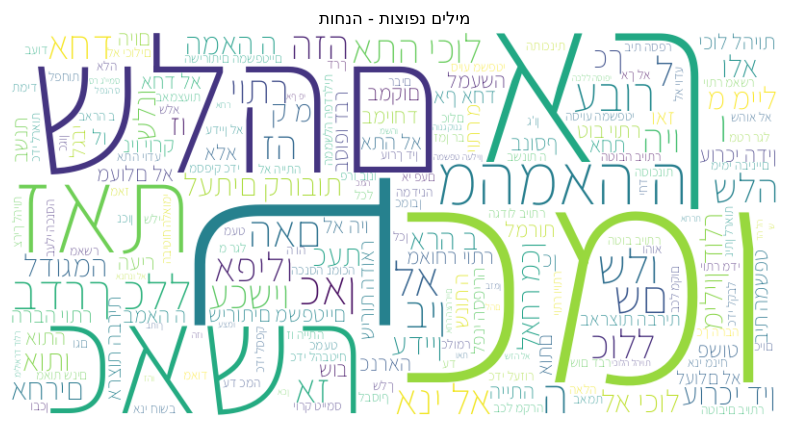

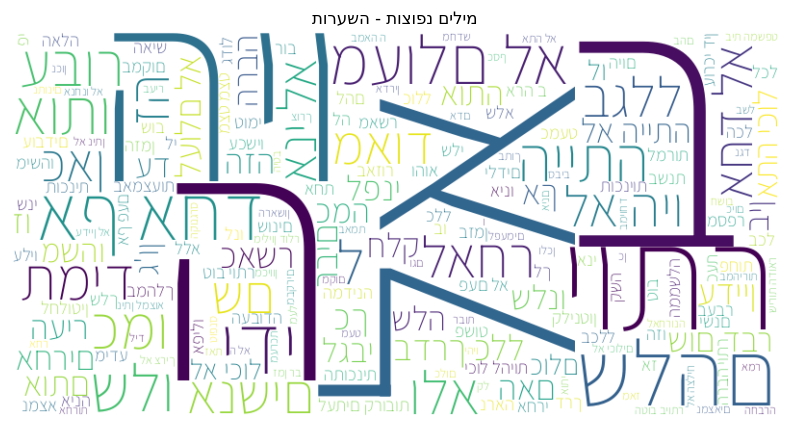

In [31]:
def create_hebrew_wordcloud(text_series, title):
    # חיבור כל הטקסט וטיפול בכיווניות (RTL)
    text = " ".join(text_series.dropna())
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)


    # בתוך הפונקציה של ה-WordCloud, הוסיפו את הפרמטר:
    wordcloud = WordCloud(
        font_path='assistant.ttf',
        width=800, height=400,
        background_color='white'
    ).generate(bidi_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(get_display(title))
    plt.savefig(f'{title}.png')

# יצירת ענני מילים בנפרד לכל חלק
create_hebrew_wordcloud(df['premise_clean'], "מילים נפוצות - הנחות")
print('')
create_hebrew_wordcloud(df['hypothesis_clean'], "מילים נפוצות - השערות")

We can see there are a lot of stop words and its hard to remove them all with out a build in ine already.


But we are going to use Encoders and Decoders so we dont need to remove the stop words.

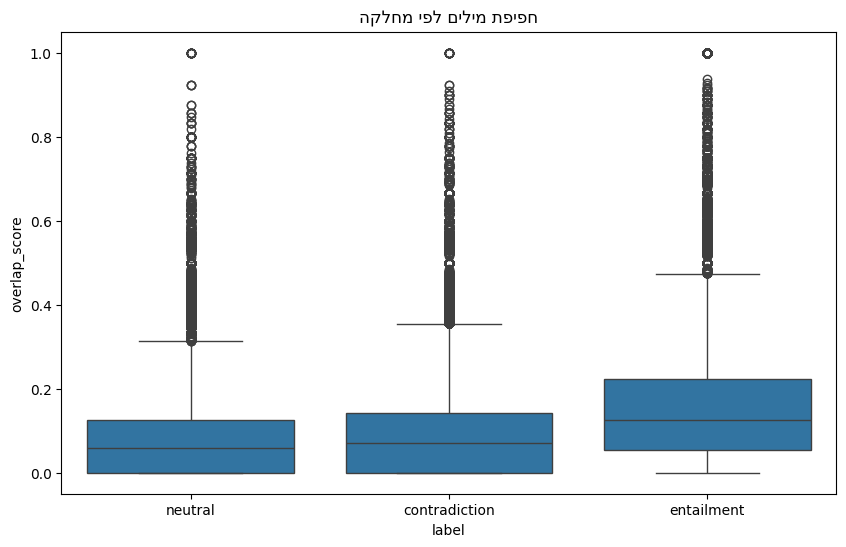

In [16]:
def jaccard_similarity(row):
    s1 = set(str(row['translation1']).split())
    s2 = set(str(row['translation2']).split())
    return len(s1.intersection(s2)) / len(s1.union(s2))

df['overlap_score'] = df.apply(jaccard_similarity, axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='overlap_score', data=df)
plt.title(get_display("חפיפת מילים לפי מחלקה"))
plt.savefig('semantic_overlap.png')

The graph shows the overlap_score (the degree of similarity between the words in the premise and those in the hypothesis) for each of the three classes:

**Entailment**: You can see that the median (the center line in the box) and quartiles are significantly higher than the other classes. This makes sense – when one sentence follows from another, they often share similar vocabulary.

**Contradiction**: The overlap is lower, indicating the use of different or contrasting words.

**Neutral**: The lowest level of overlap, indicating that in these cases the hypothesis often introduces new information that was not present in the premise.

# Check the distribution be genre:

--- כמות דוגמאות לפי ז'אנר ---
genre
government    76083
travel        74999
fiction       72756
slate         70205
letters        1930
oup            1927
nineeleven     1828
Name: count, dtype: int64


/tmp/ipython-input-2144183251.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='genre', palette='magma', order=genre_counts.index)


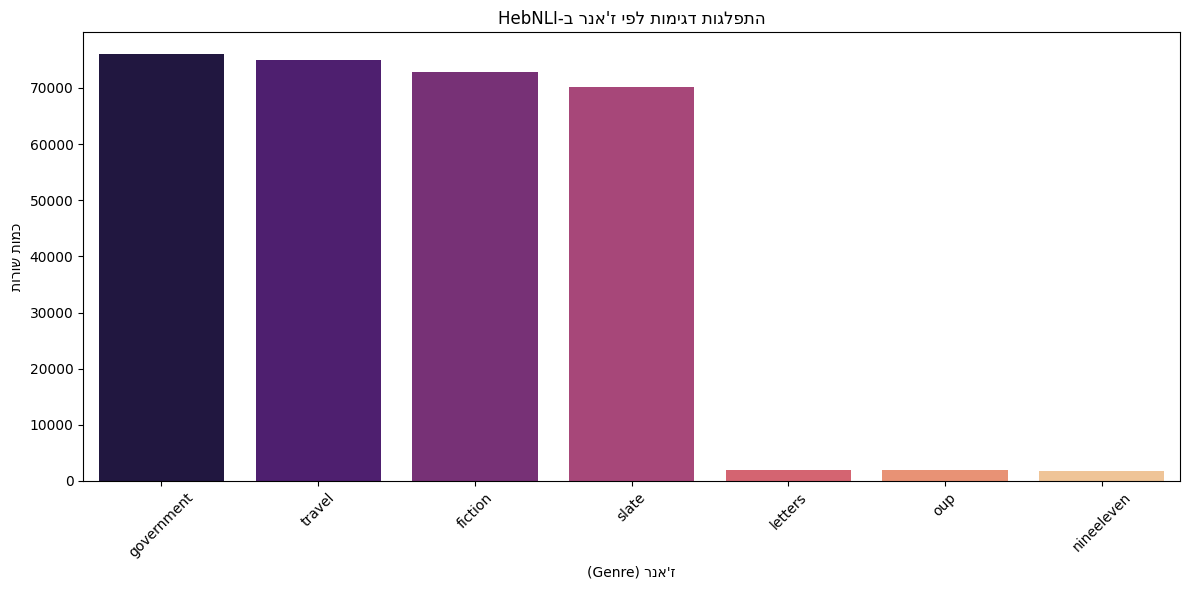

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bidi.algorithm import get_display

# 1. בדיקת כמות הדוגמאות בכל ז'אנר (בטקסט)
genre_counts = df['genre'].value_counts()
print("--- כמות דוגמאות לפי ז'אנר ---")
print(genre_counts)

# 2. יצירת ויזואליזציה (גרף)
plt.figure(figsize=(12, 6))
# שימוש ב-countplot של seaborn
ax = sns.countplot(data=df, x='genre', palette='magma', order=genre_counts.index)

# טיפול בכותרות בעברית (RTL)
plt.title(get_display("התפלגות דגימות לפי ז'אנר ב-HebNLI"))
plt.xlabel(get_display("ז'אנר (Genre)"))
plt.ylabel(get_display("כמות שורות"))

# סיבוב שמות הז'אנרים אם הם ארוכים
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('genre_distribution.png')
plt.show()

According to the graph:

The dataset includes significant representation for four major genres: Government (most common), Travel, Fiction, and Slate.

There is a sharp decrease in the number of samples for Letters, OUP, and Nine-eleven.

We noted that the model may be biased in favor of formal or descriptive language (government and travel) and less skilled at analyzing personal letters due to the lack of data.

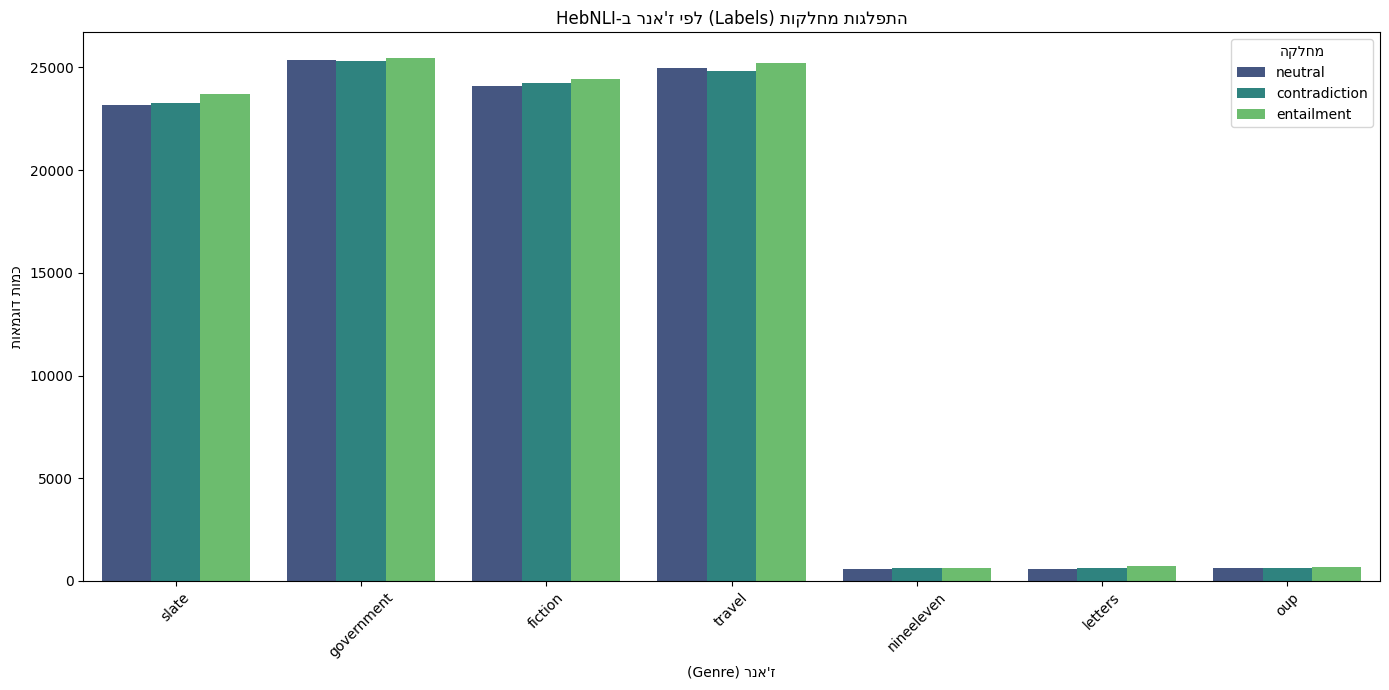

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bidi.algorithm import get_display

# 1. יצירת גרף עמודות מקובץ
plt.figure(figsize=(14, 7))

# שימוש ב-hue כדי להפריד את העמודות לפי ה-label בתוך כל genre
ax = sns.countplot(data=df, x='genre', hue='label', palette='viridis')

# 2. הפיכת הטקסט לעברית (RTL) עבור הכותרות והצירים
plt.title(get_display("התפלגות מחלקות (Labels) לפי ז'אנר ב-HebNLI"))
plt.xlabel(get_display("ז'אנר (Genre)"))
plt.ylabel(get_display("כמות דוגמאות"))

# עדכון מקרא (Legend) לעברית
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [get_display(l) for l in labels], title=get_display("מחלקה"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('genre_label_distribution.png')
plt.show()

We can see the distribution per genre had an almost even labels.    